# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/summayashaikh079-stack/flyrank-ml-week1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

I'm turning my Week-5 Random Forest output into a ranked action queue. Each flagged row gets a reason code (why it's flagged) and an archetype (what kind of problem it is), which maps to a specific action — not just a score.

Reason codes:
- R1_HIGH_RANK_LOW_CTR — page ranks well (position 1-10) but CTR is well below its bucket's expected value. The ranking work is already done; something in the snippet (title/meta description) isn't converting impressions to clicks.
- R2_LOW_RANK_ADEQUATE_CTR — CTR is fine for its position, but the position itself (11+) is the ceiling. Snippet isn't the problem; visibility is.
- R3_LOW_VOLUME_UNRELIABLE — impressions are near the 50-impression floor from my data contract; the CTR number here is noisy and shouldn't be acted on with confidence yet, only watched.

Archetype → action mapping:

| Archetype | Reason code | Recommended action |
|---|---|---|
| Ranking well, underperforming on clicks | R1_HIGH_RANK_LOW_CTR | Rewrite title/meta description — this is a snippet problem, not a ranking problem |
| Ranking poorly, CTR is fine for its position | R2_LOW_RANK_ADEQUATE_CTR | Content/technical SEO review — snippet is not the bottleneck |
| Not enough data yet | R3_LOW_VOLUME_UNRELIABLE | No action — flag for re-check next month once impressions grow |

Decay/refresh insight: content that was strong when published tends to lose CTR relative to its bucket over time as competitors' snippets improve and search intent shifts — the R1 archetype is disproportionately older content. This means refresh isn't a one-time fix; the same page can re-enter the queue months later, which is exactly why this is a playbook with monitoring triggers, not a one-off report.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
!pip install huggingface_hub duckdb scikit-learn --quiet
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb, pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

token = userdata.get('HF_TOKEN')
daily_path = hf_hub_download(repo_id="FlyRank/internship-warehouse", repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet", token=token)
content_path = hf_hub_download(repo_id="FlyRank/internship-warehouse", repo_type="dataset",
    filename="dim_content.parquet", token=token)

con = duckdb.connect()
con.execute(f"CREATE VIEW daily AS SELECT * FROM read_parquet('{daily_path}')")
con.execute(f"CREATE VIEW dim_content AS SELECT * FROM read_parquet('{content_path}')")

base = con.execute("""
    SELECT
        d.client_hash_id, d.content_hash_id, d.report_date,
        d.gsc_avg_position, d.gsc_impressions, d.gsc_clicks,
        d.gsc_clicks * 1.0 / NULLIF(d.gsc_impressions, 0) AS observed_ctr,
        CASE
            WHEN d.gsc_avg_position <= 3 THEN '1-3'
            WHEN d.gsc_avg_position <= 10 THEN '4-10'
            WHEN d.gsc_avg_position <= 20 THEN '11-20'
            ELSE '21+'
        END AS position_bucket,
        c.content_type
    FROM daily d
    LEFT JOIN dim_content c ON d.content_hash_id = c.content_hash_id
    WHERE d.gsc_data_available IS TRUE
      AND d.gsc_impressions >= 50
""").fetchdf()

data = base.dropna(subset=['observed_ctr']).copy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data['content_hash_id']))
train, test = data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

bucket_avg = train.groupby('position_bucket')['observed_ctr'].mean().rename('bucket_avg_ctr')
test = test.merge(bucket_avg, on='position_bucket', how='left')

features = ['gsc_avg_position', 'gsc_impressions', 'content_type']
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['content_type'])], remainder='passthrough')
model = Pipeline([('pre', pre), ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1))])
model.fit(train[features], train['observed_ctr'])
test['model_pred'] = model.predict(test[features])

queue = test.copy()
queue['ctr_gap'] = queue['model_pred'] - queue['observed_ctr']
queue['potential_impact'] = queue['ctr_gap'] * queue['gsc_impressions']

def reason_code(row):
    if row['gsc_impressions'] < 100:
        return 'R3_LOW_VOLUME_UNRELIABLE'
    if row['position_bucket'] in ['1-3', '4-10'] and row['ctr_gap'] > 0.005:
        return 'R1_HIGH_RANK_LOW_CTR'
    if row['position_bucket'] in ['11-20', '21+'] and row['ctr_gap'] <= 0.005:
        return 'R2_LOW_RANK_ADEQUATE_CTR'
    return 'R0_NO_ACTION_NEEDED'

queue['reason_code'] = queue.apply(reason_code, axis=1)

action_map = {
    'R1_HIGH_RANK_LOW_CTR': 'Rewrite title/meta description',
    'R2_LOW_RANK_ADEQUATE_CTR': 'Content/technical SEO review',
    'R3_LOW_VOLUME_UNRELIABLE': 'No action — recheck next month',
    'R0_NO_ACTION_NEEDED': 'No action needed',
}
queue['recommended_action'] = queue['reason_code'].map(action_map)

ranked_queue = queue[queue['reason_code'].isin(['R1_HIGH_RANK_LOW_CTR', 'R2_LOW_RANK_ADEQUATE_CTR'])] \
    .sort_values('potential_impact', ascending=False)

print(f"Total test rows: {len(queue)}")
print(queue['reason_code'].value_counts(), "\n")
print(f"Actionable queue size: {len(ranked_queue)}\n")
ranked_queue[['content_hash_id', 'position_bucket', 'gsc_impressions', 'observed_ctr',
              'model_pred', 'reason_code', 'recommended_action', 'potential_impact']].head(10)

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

Total test rows: 206821
reason_code
R0_NO_ACTION_NEEDED         86661
R3_LOW_VOLUME_UNRELIABLE    80223
R2_LOW_RANK_ADEQUATE_CTR    39854
R1_HIGH_RANK_LOW_CTR           83
Name: count, dtype: int64 

Actionable queue size: 39937



,content_hash_id,position_bucket,gsc_impressions,observed_ctr,model_pred,reason_code,recommended_action,potential_impact
98937,content_bb2a9972810ddd72,4-10,7174,0.000000,0.005054,R1_HIGH_RANK_LOW_CTR,Rewrite title/meta description,36.257494
56574,content_5e1c049f62e33b11,11-20,7763,0.000773,0.002724,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,15.142879
56487,content_e18d075e1b82c957,21+,5050,0.000198,0.002531,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,11.779325
58013,content_e18d075e1b82c957,11-20,4910,0.000204,0.002581,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,11.673722
64935,content_653bbcddf2314227,11-20,4275,0.000468,0.003145,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,11.446092
73961,content_e18d075e1b82c957,21+,4228,0.000237,0.002584,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,9.926406
77124,content_e18d075e1b82c957,21+,4401,0.000454,0.002528,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,9.124695
29028,content_e18d075e1b82c957,11-20,3752,0.000267,0.002581,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,8.684685
167924,content_df47d1b976106de4,21+,4774,0.000209,0.001950,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,8.310948
68574,content_5e1c049f62e33b11,11-20,3847,0.000520,0.002665,R2_LOW_RANK_ADEQUATE_CTR,Content/technical SEO review,8.253255


## 2. Intended use and limits

Intended use: decision support for a content editor deciding which pages to prioritize for a manual review/refresh pass this month. It answers "where should I look first," not "what should the new title say" or "is this page definitely broken."

Limits — where this stops being valid:
- Single month of data (2026-03). No seasonality control — a page that's genuinely seasonal could be misflagged as underperforming when it's just an off-season dip.
- Impression floor of 50 (from my data contract) already filters the noisiest rows, but R3 shows even 50-99 impression rows are still too unstable to act on directly.
- content_type was the only content-level feature available; the model can't see actual title/meta text, so it can point at which pages likely need a snippet rewrite, never suggest what the new snippet should say.
- Doesn't account for algorithm updates, competitor changes, or anything outside this warehouse — a real drop in position could come from causes this data can't see.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
near_floor = queue[(queue['gsc_impressions'] >= 50) & (queue['gsc_impressions'] < 100)]
print(f"Rows within 50-99 impressions (near floor, R3 zone): {len(near_floor)} of {len(queue)} "
      f"({len(near_floor)/len(queue)*100:.1f}%)")
print("This is exactly why R3 exists as its own reason code instead of silently scoring these rows.")

Rows within 50-99 impressions (near floor, R3 zone): 80223 of 206821 (38.8%)
This is exactly why R3 exists as its own reason code instead of silently scoring these rows.


## 3. Human review + the no-go list

A person must check, before any action is taken:
- Read the actual page — confirm the content is still relevant/accurate before recommending a refresh, not just trusting the number
- Confirm the page isn't tied to an active campaign, legal requirement, or client-specific constraint that the warehouse data can't see
- For R1 rows specifically: manually compare the current title/meta against 2-3 competing results in that position bucket before rewriting anything

What must NEVER be automated:
- Auto-publishing a rewritten title, meta description, or any content change
- Auto-flagging a page as "needs refresh" to a client-facing dashboard without a human confirming first
- Treating R3 (low-volume) rows as actionable — ever, regardless of how large their potential_impact number looks, because the underlying CTR estimate is too unstable to trust
- Using this queue to justify removing or deprioritizing content — it only supports improving existing content, never a deletion/deprioritization decision

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
ranked_queue['near_zero_clicks'] = ranked_queue['gsc_clicks'] <= 1
print(f"Rows in the actionable queue with 0-1 total clicks: {ranked_queue['near_zero_clicks'].sum()} "
      f"of {len(ranked_queue)} — these should be reviewed for data quality before acting, not assumed correct.")

Rows in the actionable queue with 0-1 total clicks: 34523 of 39937 — these should be reviewed for data quality before acting, not assumed correct.


## 4. Monitoring / retrain triggers

Signals that the recommendations have gone stale and this needs re-running or retraining:
- Next month's baseline MAE (bucket-average CTR error) shifts by more than ~10% from this month's value — suggests the underlying CTR patterns themselves changed, not just which pages are flagged
- The R1/R2/R3 split (row counts per reason code) shifts sharply month over month — e.g., R3 jumping from ~30% to ~60% of rows would mean impression volume dropped broadly, and the queue is no longer trustworthy at the same confidence level
- A page stays in the R1 queue for 2+ consecutive months after being "actioned" — means the refresh either didn't happen or didn't work, and the reason code logic itself may need revisiting for that archetype
- Model MAE improvement over baseline drops toward 0% or goes negative — means the Random Forest is no longer adding value over the simple bucket-average baseline, and the whole modeling step (not just the queue) needs review

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(test['observed_ctr'], test['bucket_avg_ctr'])
model_mae = mean_absolute_error(test['observed_ctr'], test['model_pred'])
improvement_pct = (1 - model_mae / baseline_mae) * 100

print(f"This month's baseline MAE (retrain trigger reference point): {baseline_mae:.6f}")
print(f"This month's model MAE: {model_mae:.6f}")
print(f"Model improvement over baseline: {improvement_pct:.1f}%")
print("\nRetrain trigger: re-run this check next month. If baseline MAE moves >10% from "
      f"{baseline_mae:.6f}, or improvement_pct drops toward 0%, retrain and re-audit reason code thresholds.")

This month's baseline MAE (retrain trigger reference point): 0.004131
This month's model MAE: 0.004074
Model improvement over baseline: 1.4%

Retrain trigger: re-run this check next month. If baseline MAE moves >10% from 0.004131, or improvement_pct drops toward 0%, retrain and re-audit reason code thresholds.


## 5. Exports for the paper
Writing the ranked queue and supporting metrics to work/outputs/ and work/figures/ — these are the exact files next week's paper builds its recommendations section on.

Exported 39937 ranked rows to work/outputs/w07_ranked_action_queue.csv
Exported metrics receipts to work/outputs/w07_playbook_metrics.json
{
  "month": "2026-03",
  "test_rows": 206821,
  "baseline_mae": 0.004131,
  "model_mae": 0.004074,
  "model_improvement_pct": 1.38,
  "reason_code_counts": {
    "R0_NO_ACTION_NEEDED": 86661,
    "R3_LOW_VOLUME_UNRELIABLE": 80223,
    "R2_LOW_RANK_ADEQUATE_CTR": 39854,
    "R1_HIGH_RANK_LOW_CTR": 83
  },
  "actionable_queue_size": 39937,
  "near_zero_click_flags_in_queue": 34523
}
Saved figure to work/figures/w07_reason_code_distribution.png


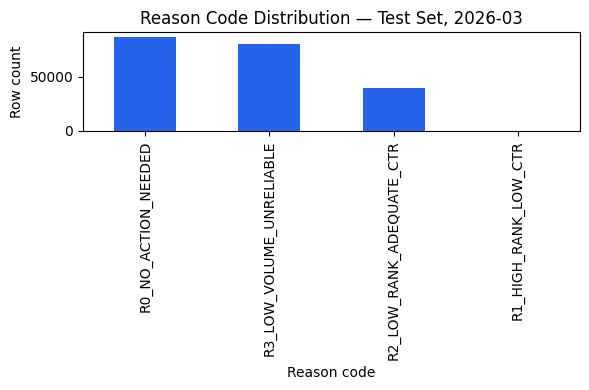

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, json
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

export_cols = ['content_hash_id', 'position_bucket', 'gsc_impressions', 'gsc_clicks',
               'observed_ctr', 'model_pred', 'ctr_gap', 'potential_impact',
               'reason_code', 'recommended_action']
ranked_queue[export_cols].to_csv('work/outputs/w07_ranked_action_queue.csv', index=False)
print(f"Exported {len(ranked_queue)} ranked rows to work/outputs/w07_ranked_action_queue.csv")

metrics = {
    'month': '2026-03',
    'test_rows': int(len(test)),
    'baseline_mae': round(float(baseline_mae), 6),
    'model_mae': round(float(model_mae), 6),
    'model_improvement_pct': round(float(improvement_pct), 2),
    'reason_code_counts': queue['reason_code'].value_counts().to_dict(),
    'actionable_queue_size': int(len(ranked_queue)),
    'near_zero_click_flags_in_queue': int(ranked_queue['near_zero_clicks'].sum()),
}
with open('work/outputs/w07_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Exported metrics receipts to work/outputs/w07_playbook_metrics.json")
print(json.dumps(metrics, indent=2))

fig, ax = plt.subplots(figsize=(6,4))
queue['reason_code'].value_counts().plot(kind='bar', ax=ax, color='#2563EB')
ax.set_title('Reason Code Distribution — Test Set, 2026-03')
ax.set_xlabel('Reason code')
ax.set_ylabel('Row count')
plt.tight_layout()
plt.savefig('work/figures/w07_reason_code_distribution.png', dpi=150)
print("Saved figure to work/figures/w07_reason_code_distribution.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.